### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [3]:
import yaml

In [4]:
# Notebook input parameters
SAVE_FIGURES = False
SAVE_TABLES = False
show_plots = False
folder_name = "XXX4weeks_1core___"

In [5]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May22_Thu_h20_m54_s05-GTSEP_stochastic_v2-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May22_Thu_h20_m54_s05-GTSEP_stochastic_v2-128_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [6]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [7]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [8]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [9]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [10]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]
yearly_discount = config.get("yearly_discount", 10)

In [11]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder, yearly_discount=yearly_discount
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [12]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [13]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [14]:
decision_varables

{'battery_capacity':                       value
 battery   year             
 ES1 0 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 1 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 2 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 3 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 4 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 5 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 6 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.000000
 ES1 7 bat 2025     0.000000
           2030     0.000000
           2040     0.000000
           2050     0.0

In [15]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [114]:
config["expansion_factor"]

0.5

In [16]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [17]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [18]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,134.800000,539.200000,539.200000,808.800000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


### Generator Investment and Capacity Plots 

In [19]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


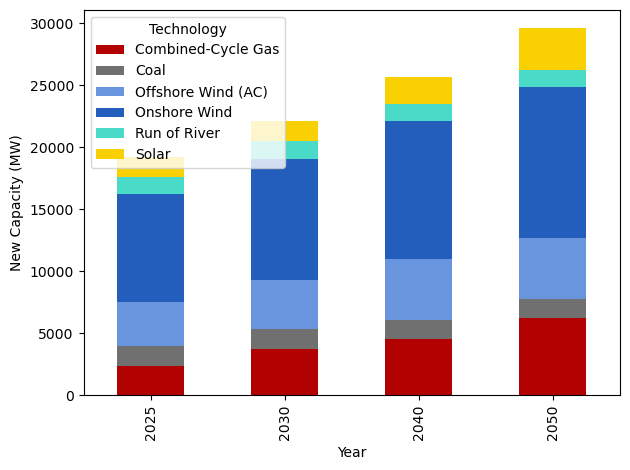

In [20]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


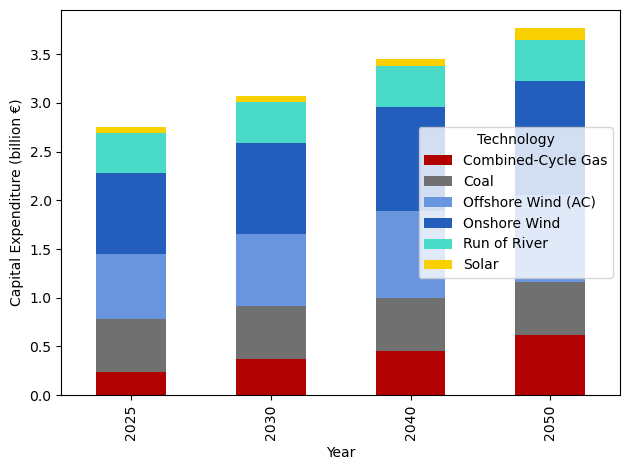

In [21]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


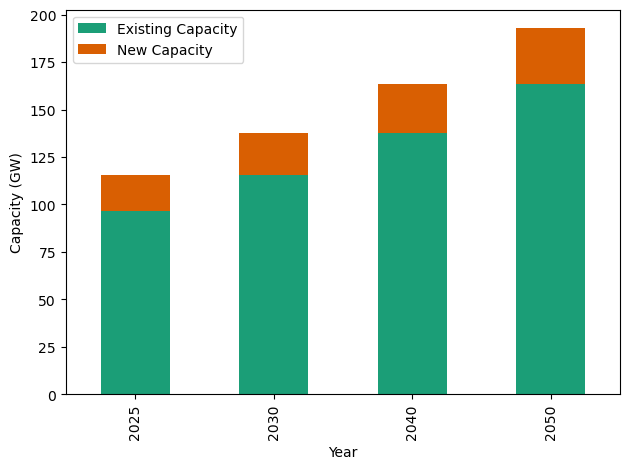

In [22]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


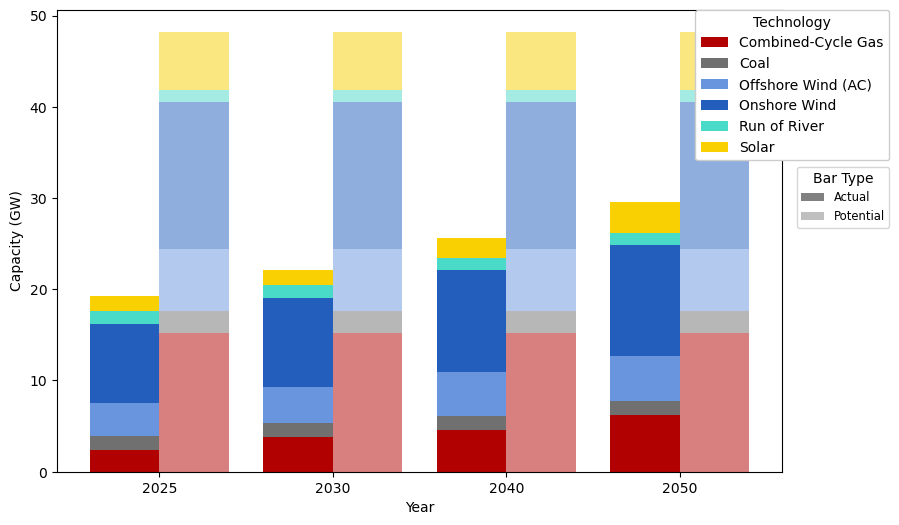

In [23]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [24]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,7.100541e+07,2.253985e+06,5.661780e+07,9.276423e+07,3.730670e+07,1.435400e+07
2030,8.224529e+07,4.682902e+06,5.835346e+07,9.655750e+07,3.724681e+07,1.433843e+07
2040,1.184413e+08,1.215155e+07,6.145511e+07,1.068435e+08,3.705735e+07,1.433929e+07
2050,1.332795e+08,1.619931e+07,6.275397e+07,1.100468e+08,3.693937e+07,1.435822e+07


In [25]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        7.100541e+07  2.253985e+06  5.661780e+07  9.276423e+07   
2030 NT        8.224529e+07  4.682902e+06  5.835346e+07  9.655750e+07   
2040 DE        4.300794e+07  4.868382e+06  2.080366e+07  3.646949e+07   
     GA        3.428228e+07  2.879266e+06  2.006098e+07  3.430940e+07   
     NT        4.115108e+07  4.403899e+06  2.059046e+07  3.606458e+07   
2050 DE        7.382546e+07  1.012216e+07  3.208364e+07  5.645632e+07   
     GA        5.945406e+07  6.077152e+06  3.067033e+07  5.359045e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        3.730670e+07  1.435400e+07  2.743021e+08  
2030 NT        3.724681e+07  1.433843e+07  2.934244e+08  
2040 DE        1.233954e+07  4.772252e+06  1.222613e+08  
     GA        1.236713e+07  4.785583e+06  1.086846e+08  
     NT        1.235068e+07  4.781458e+06  1.193422e+08  
2050 DE        1.840652e+07  7.178211e+06  1.980723e+08  
     GA        1.853286e+07  7.180012e+06  1.755049e+08

In [26]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,3.896253e+09,1.248639e+08,849267.037130,1.391463e+06,0.0,143539.995499,4.023501e+09
2030,4.513091e+09,2.594186e+08,875301.943838,1.448362e+06,0.0,143384.255519,4.774977e+09
2040,6.499529e+09,6.731589e+08,921826.580540,1.602652e+06,0.0,143392.924553,7.175356e+09
2050,7.315223e+09,8.973928e+08,941309.544444,1.650702e+06,0.0,143582.232431,8.215352e+09


In [27]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,7.100541e+07,2.253985e+06,5.661780e+07,9.276423e+07,3.730670e+07,1.435400e+07,2.743021e+08
2030,8.224529e+07,4.682902e+06,5.835346e+07,9.655750e+07,3.724681e+07,1.433843e+07,2.934244e+08
2040,1.184413e+08,1.215155e+07,6.145511e+07,1.068435e+08,3.705735e+07,1.433929e+07,3.502881e+08
2050,1.332795e+08,1.619931e+07,6.275397e+07,1.100468e+08,3.693937e+07,1.435822e+07,3.735772e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


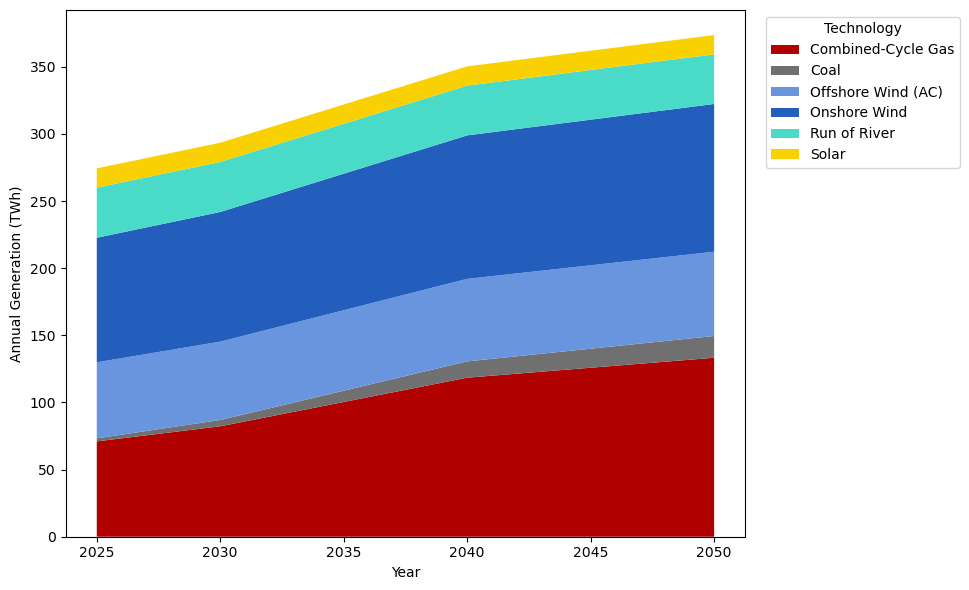

Evolution of Annual Energy Production by Technology (averaged across scenarios)


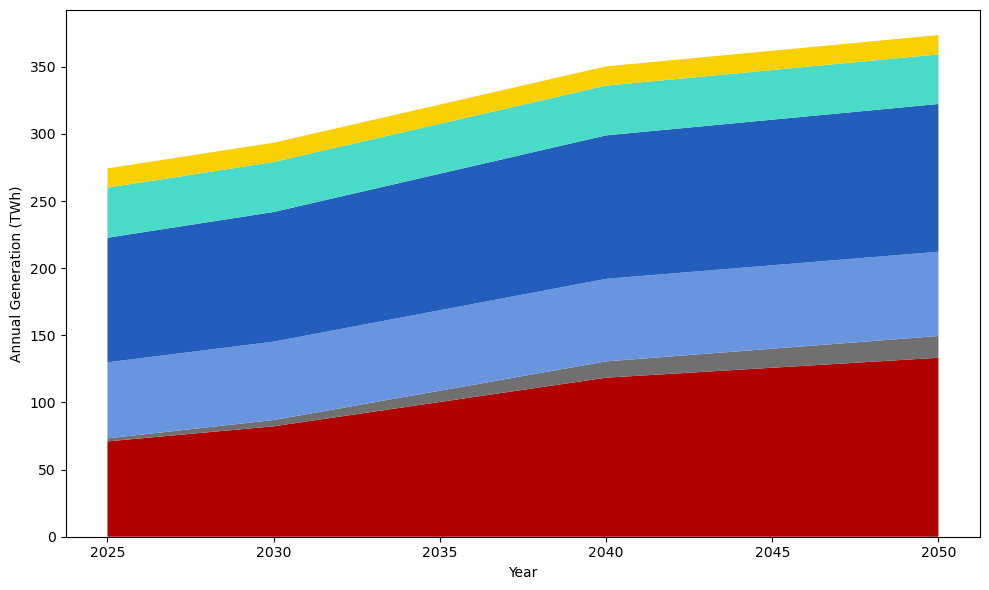

In [28]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


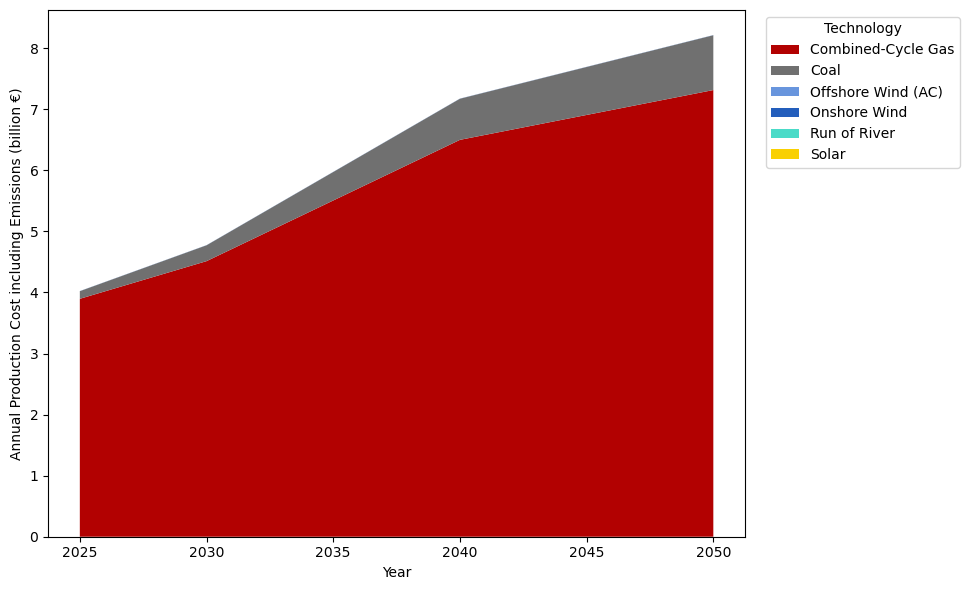

In [29]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [30]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.743021e+08  1.496744e+07       1.197395e+09     2.826106e+09   
2030 NT        2.934244e+08  1.804124e+07       1.443300e+09     3.331677e+09   
2040 DE        3.667838e+08  3.077051e+07       2.461641e+09     5.430821e+09   
     GA        3.260539e+08  2.350622e+07       1.880498e+09     4.243982e+09   
     NT        3.580265e+08  2.918263e+07       2.334610e+09     5.174517e+09   
2050 DE        3.961446e+08  3.641325e+07       2.913060e+09     6.316773e+09   
     GA        3.510097e+08  2.791409e+07       2.233127e+09     4.967743e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         4.023501e+09  
2030 NT                         4.774977e+09  
2040 DE                         7.892462e+09  
     GA                         6.124479e+09  
     NT                         7.509127e+09  
2050 DE                         9.229834e+09  
     GA                         7.200870e+09

CO₂ Emissions by Year and Scenario


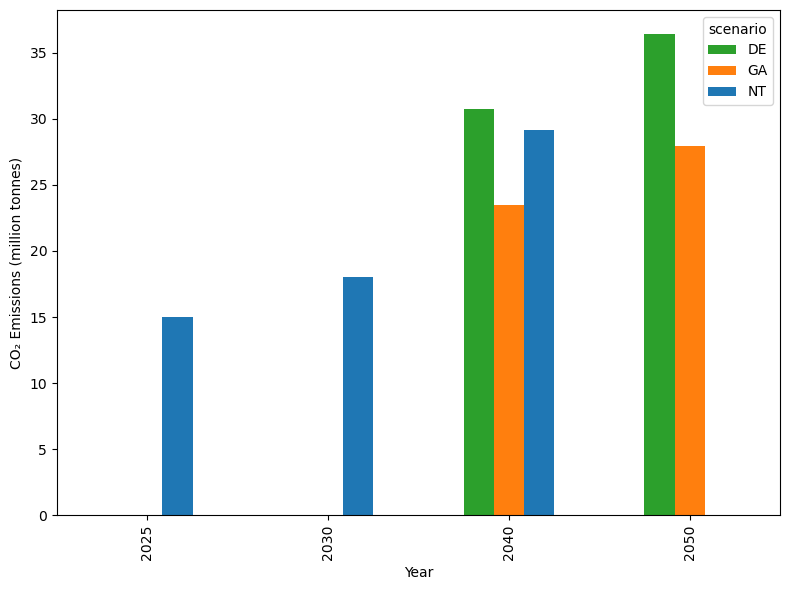

CO₂ Emissions by Year, Scenario, and Average


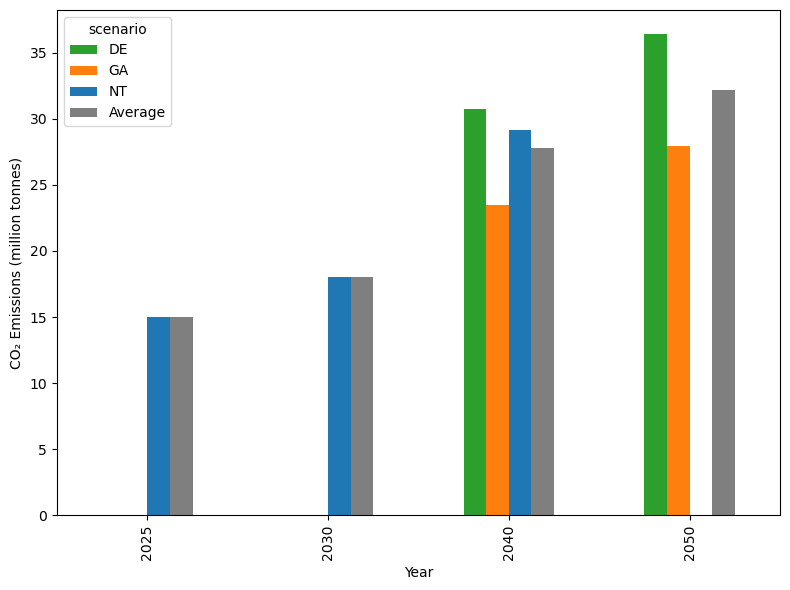

Annual Production by Year, Scenario, and Average


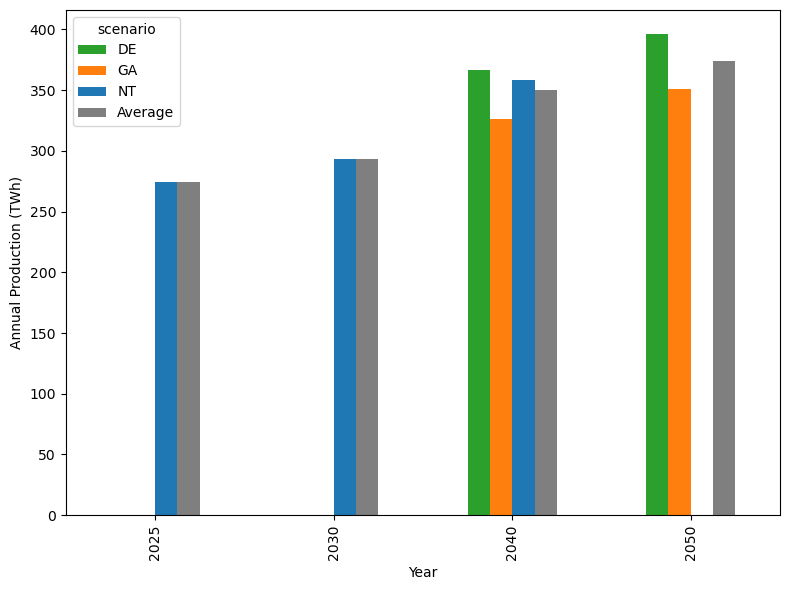

Production Cost by Year, Scenario, and Average


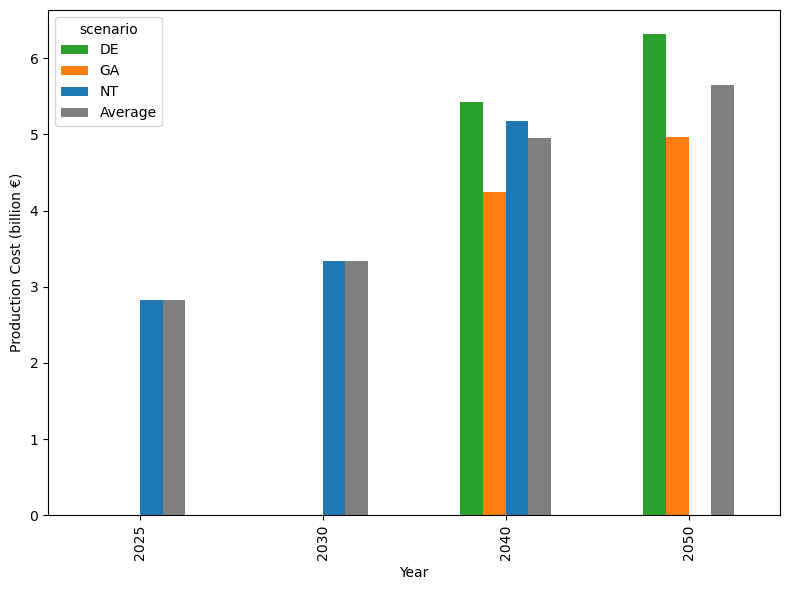

Production Cost w/ Emissions by Year, Scenario, and Average


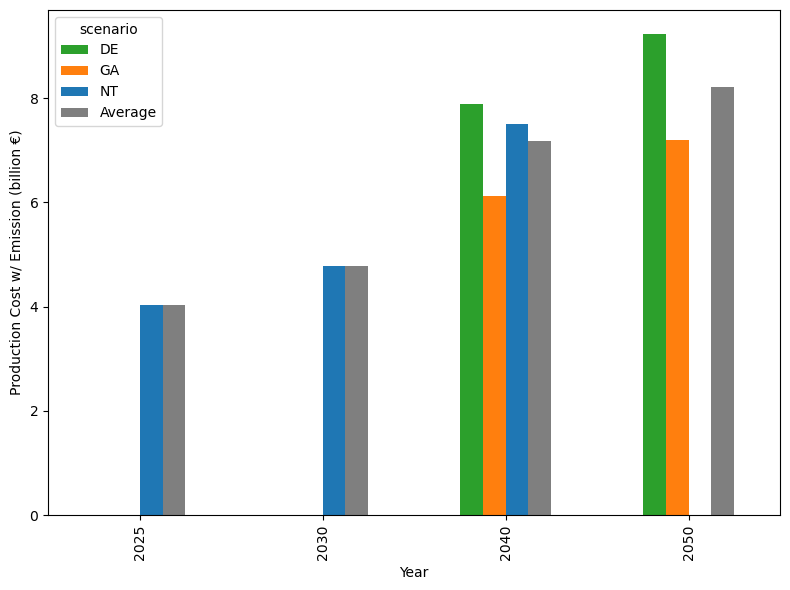

In [31]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [32]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [33]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [113]:
scenarios

{'2025': ['NT'],
 '2030': ['NT'],
 '2040': ['NT', 'GA', 'DE'],
 '2050': ['GA', 'DE']}

capacity_factors shape: (35040, 51)
cf_weekly shape: (208, 51)
weighted_cf shape: (208, 51)
annual_cf shape: (4, 51)
cap_df shape: (4, 51)
Sample of potential_car: carrier          CCGT          coal    offwind-ac        onwind           ror  \
year                                                                            
2025     2.877185e+08  5.521706e+07  4.564478e+07  9.347821e+07  1.915410e+07   
2030     3.206464e+08  6.891703e+07  5.731402e+07  1.180699e+08  2.553880e+07   
2040     3.604426e+08  8.261701e+07  7.074098e+07  1.453399e+08  3.192351e+07   
2050     4.149807e+08  9.631698e+07  8.416793e+07  1.747331e+08  3.830821e+07   

carrier         solar  
year                   
2025     1.930268e+07  
2030     2.140728e+07  
2040     2.424525e+07  
2050     2.863713e+07  
potential shape: (4, 51)
Sample of capacity_factors:                 ES1 0 offwind-ac  ES1 0 onwind  ES1 0 solar  ES1 1 offwind-ac  \
year week hour                                                         

c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2491: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2492: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


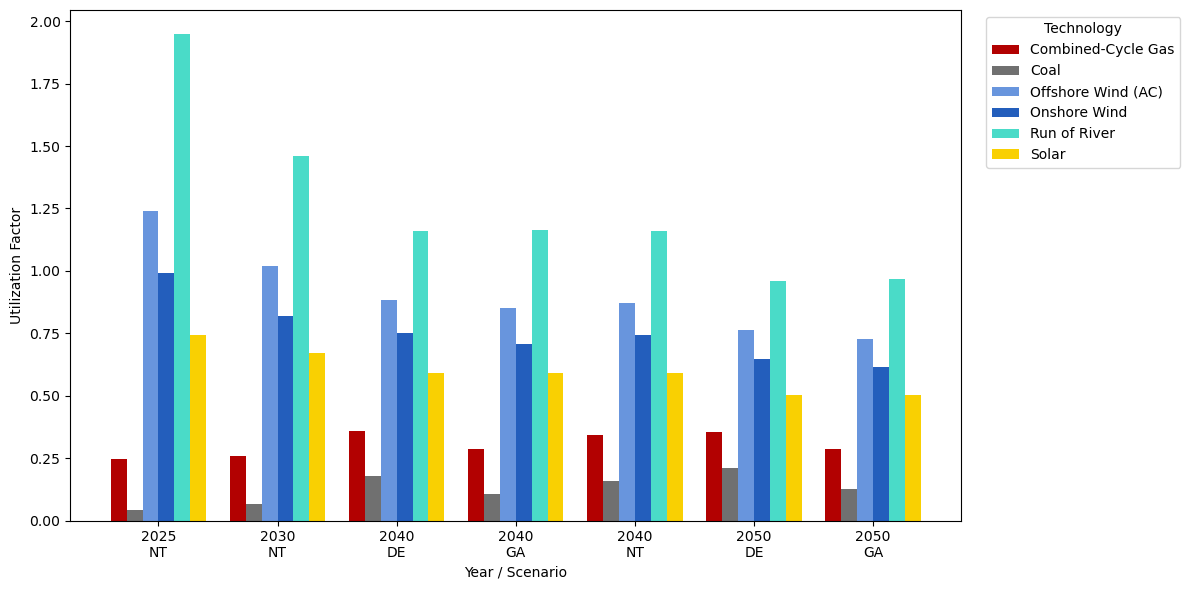

In [34]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [35]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [36]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,19211.887930,51,29,2.752396e+09,2.743021e+08,1.496744e+07,1.197395e+09,2.826106e+09,4.023501e+09,6.775897e+09
2030,48228.204285,22080.274449,51,31,3.066625e+09,2.934244e+08,1.804124e+07,1.443300e+09,3.331677e+09,4.774977e+09,7.841602e+09
2040,48228.204285,25637.624661,51,35,3.453589e+09,3.502881e+08,2.781979e+07,2.225583e+09,4.949773e+09,7.175356e+09,1.062894e+10
2050,48228.204285,29589.660874,51,38,3.764546e+09,3.735772e+08,3.216367e+07,2.573094e+09,5.642258e+09,8.215352e+09,1.197990e+10


In [37]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              15225.166000   2394.250000                         11   
     coal               2369.696741   1563.923841                          5   
     offwind-ac         6867.326111   3573.979248                          9   
     onwind            16019.751672   8681.796516                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   1605.184202                         11   
2030 CCGT              15225.166000   3758.886590                         11   
     coal               2369.696741   1563.923841                          5   
     offwind-ac         6867.326111   3972.606105                          9   
     onwind            16019.751672   9786.919587                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   1605.184202                         11   
2040 CCGT              15225.166000   4542.945671                         11   
     coal               2369.696741   1563.923841                          5   
     offwind-ac         6867.326111   4854.258274                          9   
     onwind            16019.751672  11120.196373                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   2163.546378                         11   
2050 CCGT              15225.166000   6225.807000                         11   
     coal               2369.696741   1563.923841                          5   
     offwind-ac         6867.326111   4854.258274                          9   
     onwind            16019.751672  12176.590590                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   3376.327045                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              4      2.370971e+08      7.100541e+07   
     coal                              3      5.473367e+08      2.253985e+06   
     offwind-ac                        6      6.599872e+08      5.661780e+07   
     onwind                            7      8.341981e+08      9.276423e+07   
     ror                               4      4.166288e+08      3.730670e+07   
     solar                             5      5.714788e+07      1.435400e+07   
2030 CCGT                              5      3.721964e+08      8.224529e+07   
     coal                              3      5.473210e+08      4.682902e+06   
     offwind-ac                        7      7.330740e+08      5.835346e+07   
     onwind                            7      9.402870e+08      9.655750e+07   
     ror                               4      4.166149e+08      3.724681e+07   
     solar                             5      5.713183e+07      1.433843e+07   
2040 CCGT                              6      4.497867e+08      1.184413e+08   
     coal                              3      5.473054e+08      1.215155e+07   
     offwind-ac                        7      8.946409e+08      6.145511e+07   
     onwind                            8      1.068272e+09      1.068435e+08   
     ror                               4      4.166009e+08      3.705735e+07   
     solar                             7      7.698346e+07      1.433929e+07   
2050 CCGT                              6      6.163408e+08      1.332795e+08   
     coal                              3      5.472898e+08      1.619931e+07   
     offwind-ac                        7      8.945923e+08      6.275397e+07   
     onwind                            9      1.169633e+09      1.100468e+08   
     ror        

## Transmission Lines

In [38]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [39]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [40]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [41]:
branches["capital_cost"]

year  line
2025  88      23102.962586
2030  88      23092.962586
2040  88      23082.962586
2050  88      23072.962586
2025  89      11729.199350
                  ...     
2050  107     22031.025373
2025  219     14480.882016
2030  219     14470.882016
2040  219     14460.882016
2050  219     14450.882016
Name: capital_cost, Length: 76, dtype: float64

Annual New Branch Capacity Additions


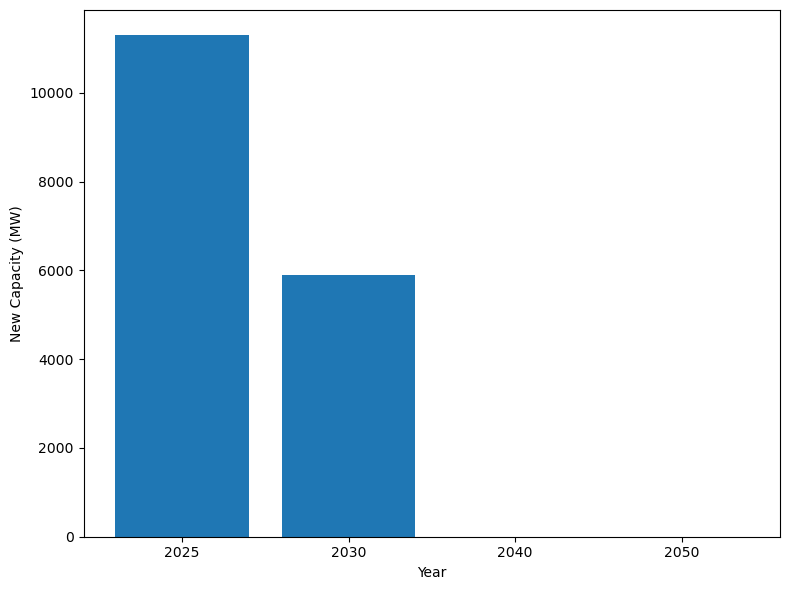

In [42]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [43]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11303.523105,19,3,2.099294e+08
2030,95000,5891.960801,19,2,8.620554e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [44]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.965309         0.894345
              2050          0.940977         0.839286
     GA       2040          0.982884         0.947917
              2050          0.972867         0.918155
     NT       2025          0.994871         0.989583
...                              ...              ...
219  GA       2040          0.886150         0.556548
              2050          0.894603         0.537202
     NT       2025          0.701970         0.113095
              2030          0.865688         0.500000
              2040          0.898873         0.535714

[133 rows x 2 columns]

In [45]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.641169         0.512453
2030 NT                0.686378         0.550282
2040 DE                0.689064         0.540179
     GA                0.688391         0.546992
     NT                0.690488         0.543155
2050 DE                0.686831         0.535636
     GA                0.689227         0.543311

Transmission line investments in 2025:


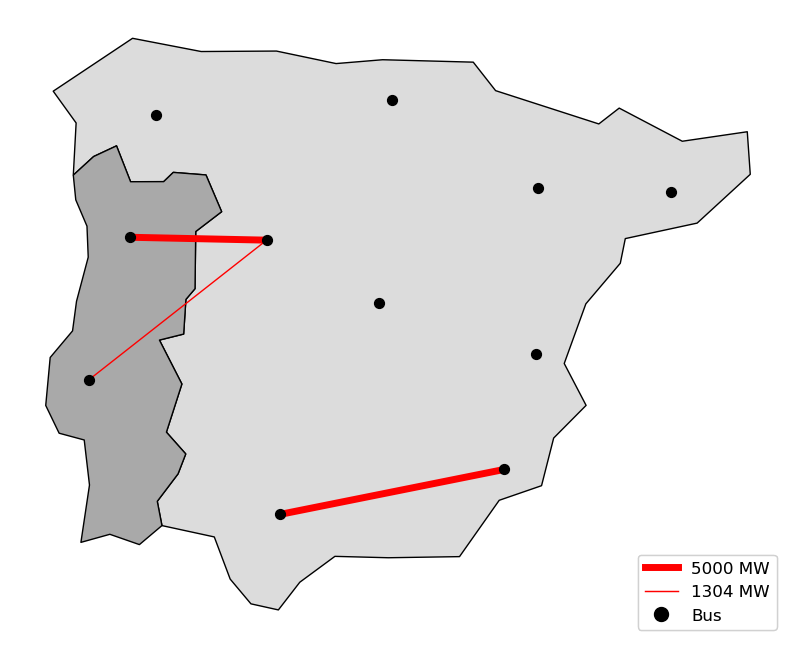

Plotting grid with new branches in year 2025
Transmission line investments in 2030:


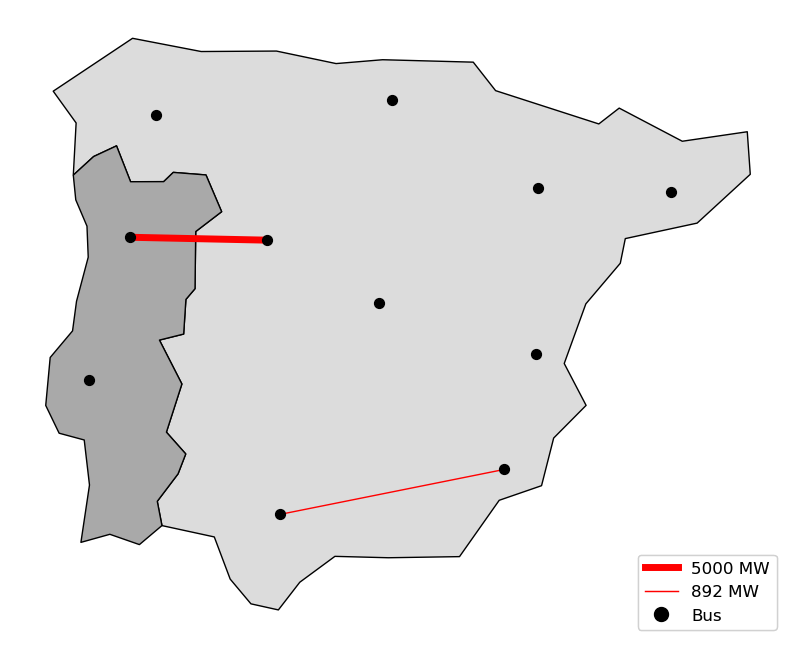

Plotting grid with new branches in year 2030


In [46]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [47]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

Annual Battery Capacity Investments


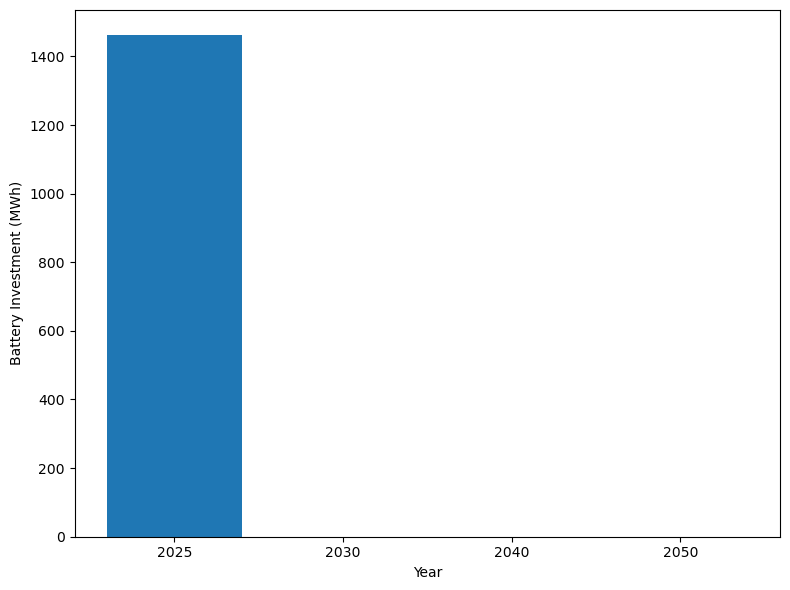

Annual Battery Investment Cost (million €)


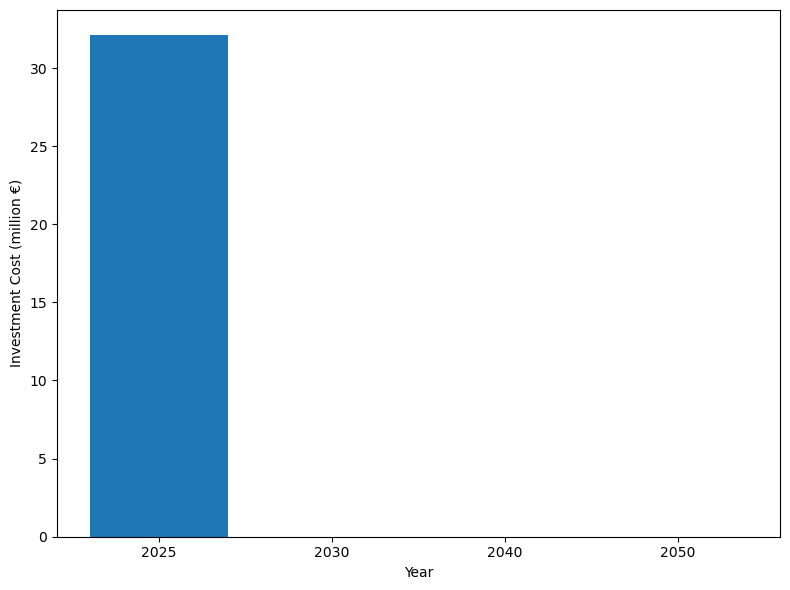

Number of 320 MWh Cycles by Year, Scenario, and Average


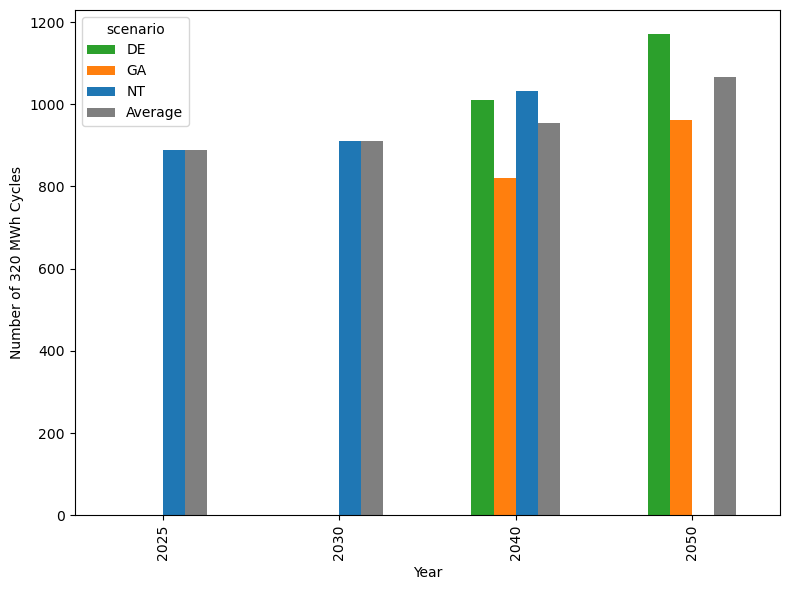

In [48]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

In [49]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,1,1462.178077,3.210786e+07,194.512876
2030,0,1462.178077,0.000000e+00,199.062419
2040,0,1462.178077,0.000000e+00,208.750150
2050,0,1462.178077,0.000000e+00,233.302717


Annual Curtailment by Year and Scenario


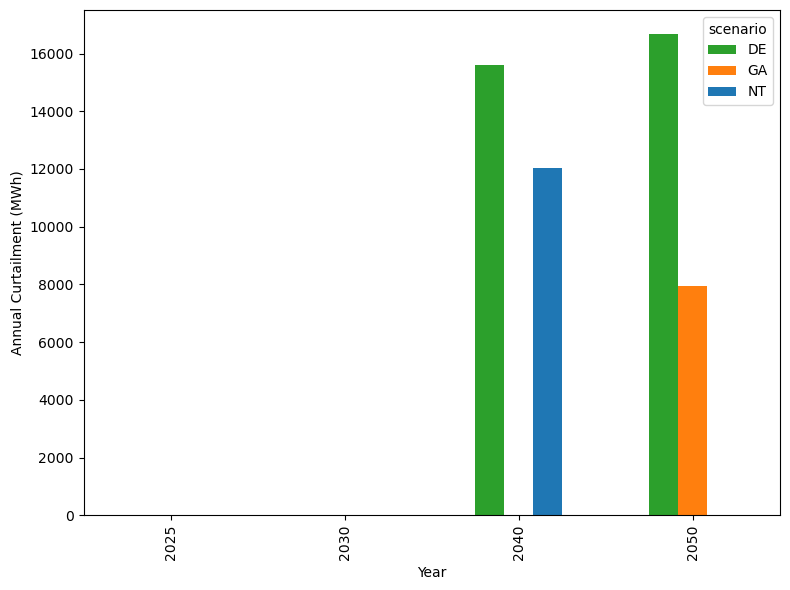

Annual Load Shedding by Year and Scenario


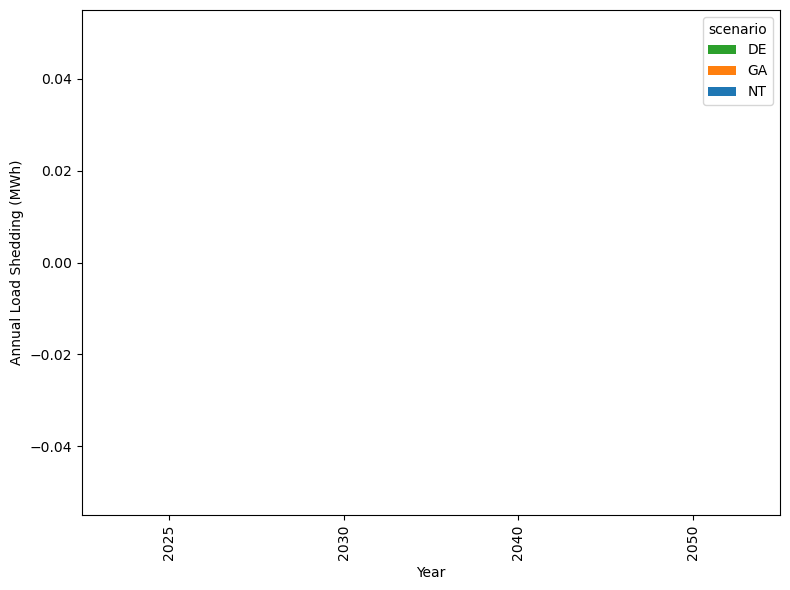

In [50]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [51]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding   curtailment  load_shedding_cost  \
year scenario                                                    
2025 NT                  0.0      0.000000                 0.0   
2030 NT                  0.0      0.000000                 0.0   
2040 DE                  0.0  15599.980126                 0.0   
     GA                  0.0      0.000000                 0.0   
     NT                  0.0  12032.420893                 0.0   
2050 DE                  0.0  16676.907361                 0.0   
     GA                  0.0   7956.578476                 0.0   

               curtailment_cost  
year scenario                    
2025 NT            0.000000e+00  
2030 NT            0.000000e+00  
2040 DE            1.559998e+06  
     GA            0.000000e+00  
     NT            1.203242e+06  
2050 DE            1.667691e+06  
     GA            7.956578e+05

## Macro analysis

In [52]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [53]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [54]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,19211.887930,51,29,2.752396e+09,2.743021e+08,1.496744e+07,1.197395e+09,2.826106e+09,4.023501e+09,6.775897e+09
2030,48228.204285,22080.274449,51,31,3.066625e+09,2.934244e+08,1.804124e+07,1.443300e+09,3.331677e+09,4.774977e+09,7.841602e+09
2040,48228.204285,25637.624661,51,35,3.453589e+09,3.502881e+08,2.781979e+07,2.225583e+09,4.949773e+09,7.175356e+09,1.062894e+10
2050,48228.204285,29589.660874,51,38,3.764546e+09,3.735772e+08,3.216367e+07,2.573094e+09,5.642258e+09,8.215352e+09,1.197990e+10


In [55]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [56]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,1,1462.178077,3.210786e+07,194.512876
2030,0,1462.178077,0.000000e+00,199.062419
2040,0,1462.178077,0.000000e+00,208.750150
2050,0,1462.178077,0.000000e+00,233.302717


In [57]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [58]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11303.523105,19,3,2.099294e+08
2030,95000,5891.960801,19,2,8.620554e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [59]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.743021e+08  1.496744e+07       1.197395e+09     2.826106e+09   
2030 NT        2.934244e+08  1.804124e+07       1.443300e+09     3.331677e+09   
2040 DE        3.667838e+08  3.077051e+07       2.461641e+09     5.430821e+09   
     GA        3.260539e+08  2.350622e+07       1.880498e+09     4.243982e+09   
     NT        3.580265e+08  2.918263e+07       2.334610e+09     5.174517e+09   
2050 DE        3.961446e+08  3.641325e+07       2.913060e+09     6.316773e+09   
     GA        3.510097e+08  2.791409e+07       2.233127e+09     4.967743e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         4.023501e+09  
2030 NT                         4.774977e+09  
2040 DE                         7.892462e+09  
     GA                         6.124479e+09  
     NT                         7.509127e+09  
2050 DE                         9.229834e+09  
     GA                         7.200870e+09

In [60]:
curtailment_and_load_shedding_table

load_shedding   curtailment  load_shedding_cost  \
year scenario                                                    
2025 NT                  0.0      0.000000                 0.0   
2030 NT                  0.0      0.000000                 0.0   
2040 DE                  0.0  15599.980126                 0.0   
     GA                  0.0      0.000000                 0.0   
     NT                  0.0  12032.420893                 0.0   
2050 DE                  0.0  16676.907361                 0.0   
     GA                  0.0   7956.578476                 0.0   

               curtailment_cost  
year scenario                    
2025 NT            0.000000e+00  
2030 NT            0.000000e+00  
2040 DE            1.559998e+06  
     GA            0.000000e+00  
     NT            1.203242e+06  
2050 DE            1.667691e+06  
     GA            7.956578e+05

Annual System Costs (average across scenarios)


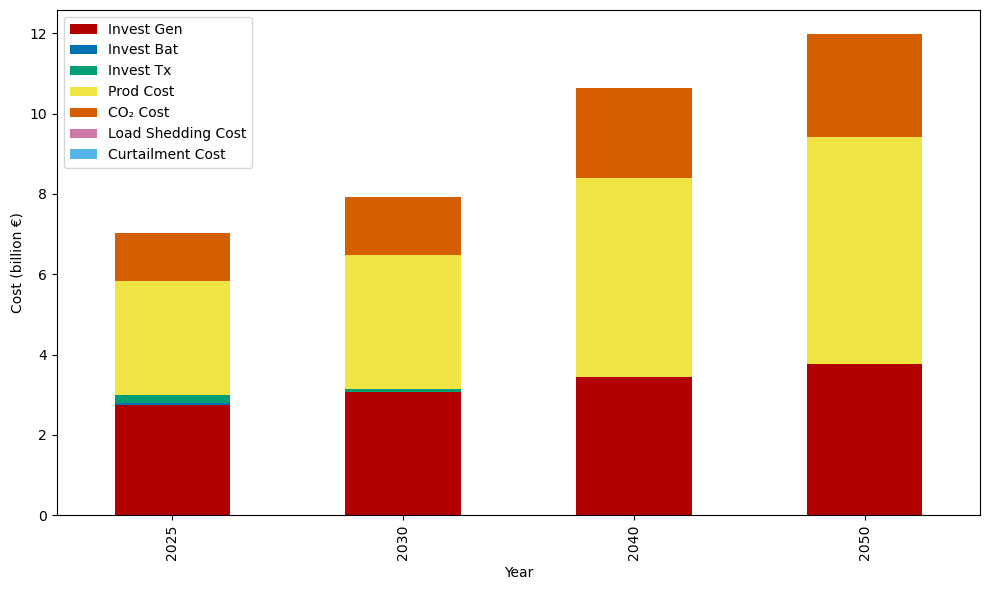

Annual System Costs by Scenario


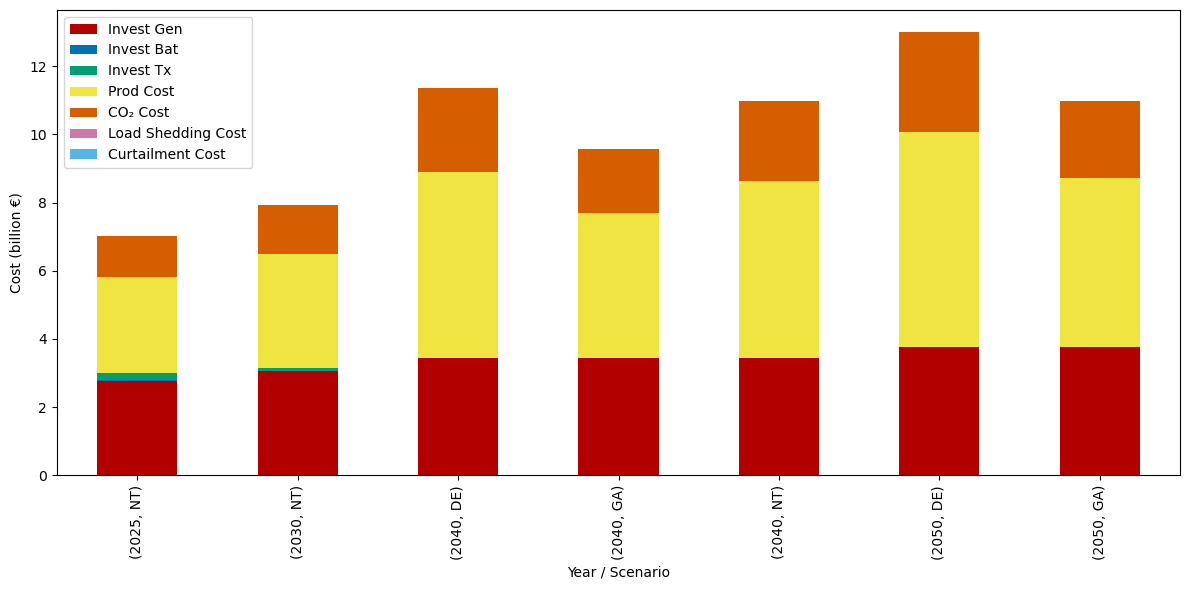

In [61]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [62]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,2.994433e+09,4.023501e+09,7.017934e+09
2030,3.152831e+09,4.774977e+09,7.927807e+09
2040,3.453589e+09,7.176277e+09,1.062987e+10
2050,3.764546e+09,8.216583e+09,1.198113e+10


In [63]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [64]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen    Invest Bat     Invest Tx  Production Cost  \
year scenario                                                              
2025 NT        2.752396e+09  3.210786e+07  2.099294e+08     2.826106e+09   
2030 NT        3.066625e+09  0.000000e+00  8.620554e+07     3.331677e+09   
2040 DE        3.453589e+09  0.000000e+00  0.000000e+00     5.430821e+09   
     GA        3.453589e+09  0.000000e+00  0.000000e+00     4.243982e+09   
     NT        3.453589e+09  0.000000e+00  0.000000e+00     5.174517e+09   
2050 DE        3.764546e+09  0.000000e+00  0.000000e+00     6.316773e+09   
     GA        3.764546e+09  0.000000e+00  0.000000e+00     4.967743e+09   
All  All       1.303716e+10  3.210786e+07  2.961349e+08     1.674981e+10   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             1.197395e+09                 0.0      0.000000e+00   
2030 NT             1.443300e+09                 0.0      0.000000e+00   
2040 DE             2.461641e+09                 0.0      1.559998e+06   
     GA             1.880498e+09                 0.0      0.000000e+00   
     NT             2.334610e+09                 0.0      1.203242e+06   
2050 DE             2.913060e+09                 0.0      1.667691e+06   
     GA             2.233127e+09                 0.0      7.956578e+05   
All  All            7.439371e+09                 0.0      2.152754e+06   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         4.023501e+09  2.994433e+09  4.023501e+09  7.017934e+09  
2030 NT         4.774977e+09  3.152831e+09  4.774977e+09  7.927807e+09  
2040 DE         7.892462e+09  3.453589e+09  7.894022e+09  1.134761e+10  
     GA         6.124479e+09  3.453589e+09  6.124479e+09  9.578068e+09  
     NT         7.509127e+09  3.453589e+09  7.510330e+09  1.096392e+10  
2050 DE         9.229834e+09  3.764546e+09  9.231501e+09  1.299605e+10  
     GA         7.200870e+09  3.764546e+09  7.201665e+09  1.096621e+10  
All  All        2.418919e+10  1.336540e+10  2.419134e+10  3.755674e+10

In [65]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,134.800000,539.200000,539.200000,808.800000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


In [66]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [67]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0       0.000000
                             1      -0.000141

------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014990
                         1       0.014869

------------------------


In [68]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [69]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0       0.000000
                             1      -0.000141

dual_value    p  weight
battery   scenario year week hour                         
ES1 0 bat NT       2025 11   0       0.000000  1.0     1.0
                             1      -0.000141  1.0     1.0

battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014990
                         1       0.014869

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014990  1.0     1.0
                         1       0.014869  1.0     1.0

In [70]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [71]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [72]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [73]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        38.762693  38.239534  38.702957  38.395956  38.708880   
2030 NT        39.467161  39.218685  39.692557  39.375384  39.696290   
2040 DE        43.394651  43.039947  43.555873  43.216477  43.566296   
     GA        41.896141  41.503090  42.001132  41.675569  42.014868   
     NT        43.120187  42.740806  43.252127  42.916709  43.264099   
2050 DE        45.766629  45.466610  46.002644  45.650344  46.019322   
     GA        43.019642  42.626322  43.135419  42.802702  43.149153   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        38.814824  39.175858  39.179547  39.072458  38.767791   
2030 NT        39.804936  40.177550  40.178963  40.071505  40.016224   
2040 DE        43.687933  44.088070  44.098446  43.971704  43.875276   
     GA        42.130214  42.514333  42.526091  42.402120  42.328797   
     NT        43.384894  43.780614  43.792561  43.665059  43.571926   
2050 DE        46.148350  46.564738  46.581983  46.441835  46.333933   
     GA        43.269643  43.662480  43.676226  43.547237  43.458312   

node               PT1 1  
year scenario             
2025 NT        39.181342  
2030 NT        40.292706  
2040 DE        44.162484  
     GA        42.598459  
     NT        43.855586  
2050 DE        46.660461  
     GA        43.738604

In [74]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,38.818349,38.818349
2030,NaN,NaN,39.817451,39.817451
2040,43.696105,42.144620,43.394961,43.078562
2050,46.148804,43.280522,NaN,44.714663


Average LMP by Year and Scenario (±1 std)


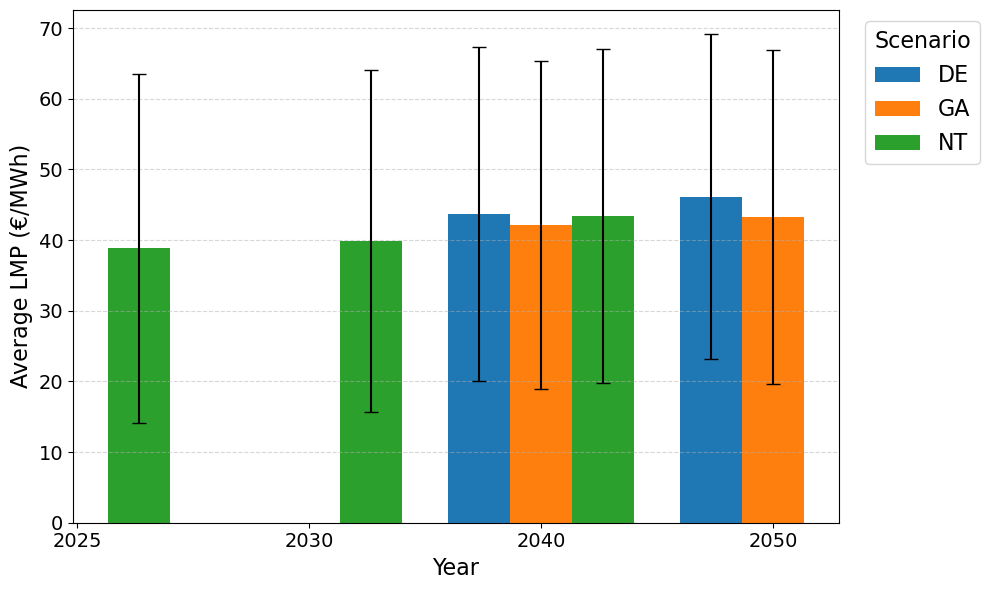

In [75]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


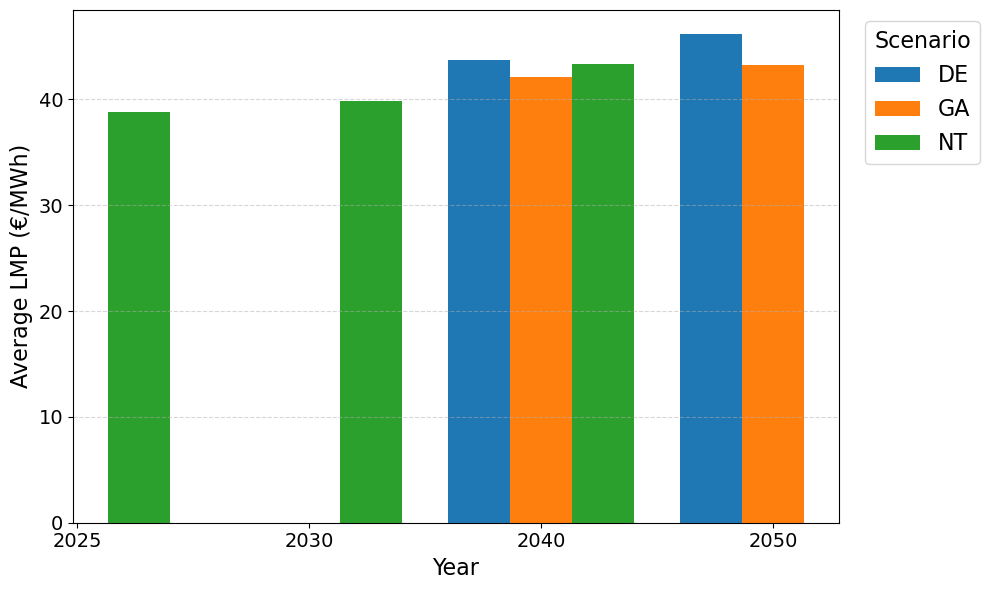

In [76]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


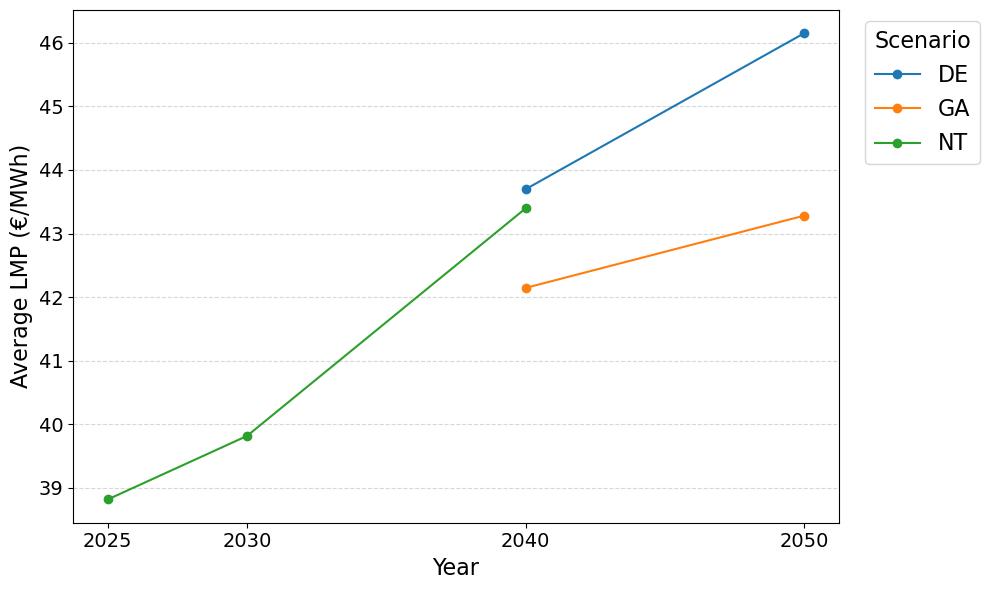

In [77]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


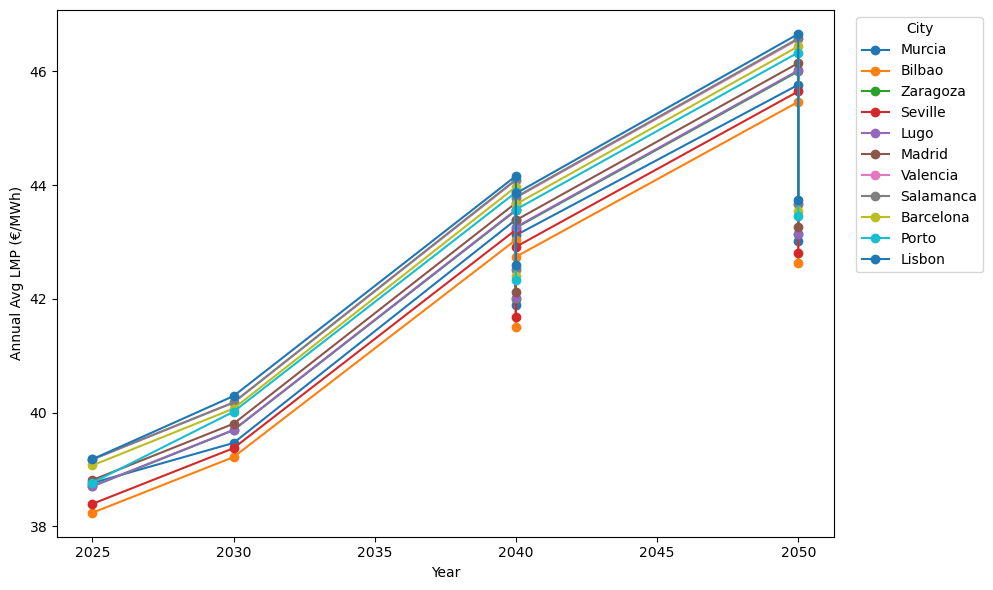

In [78]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


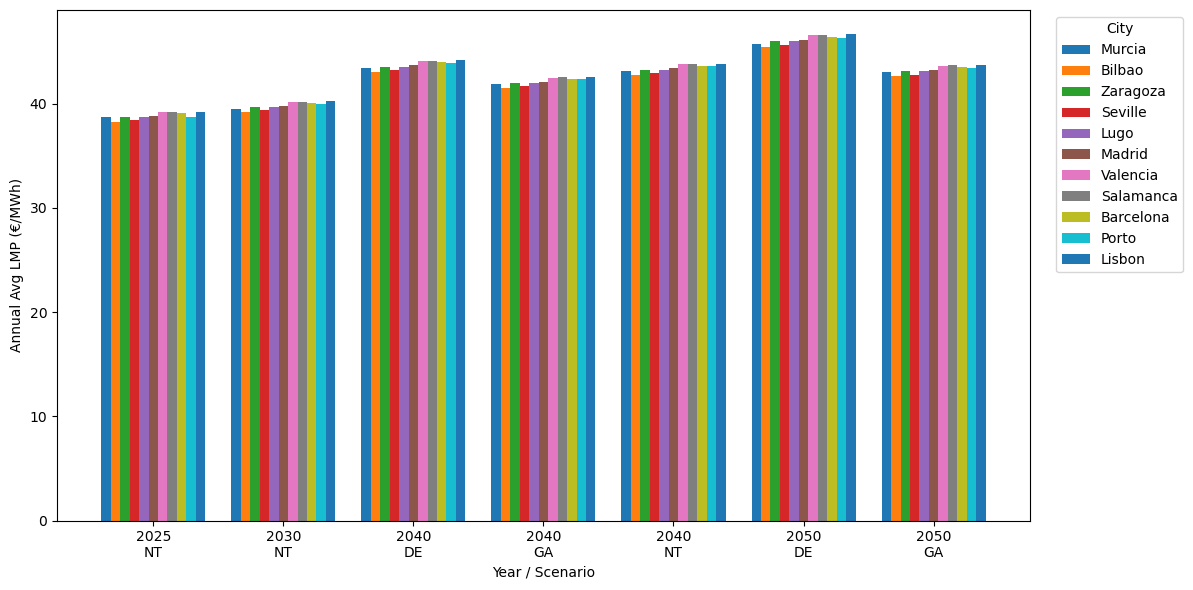

In [79]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [80]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year             
88   2025 -9004.677375
     2030     0.000000
     2040     0.000000
     2050     0.000000
89   2025     0.000000
...                ...
107  2050     0.000000
219  2025     0.000000
     2030     0.000000
     2040     0.000000
     2050     0.000000

[76 rows x 1 columns]

In [81]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [82]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 56.65078907769784
Year: 2030, Scenario: NT, max dual: 57.911107421396125
Year: 2040, Scenario: NT, max dual: 59.1781081741198
Year: 2040, Scenario: GA, max dual: 58.483087770486605
Year: 2040, Scenario: DE, max dual: 59.1781081741198
Year: 2050, Scenario: GA, max dual: 59.17810817411981
Year: 2050, Scenario: DE, max dual: 60.24621278331866


In [83]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,99,0.191327
gap_curtailment_neg_thermal,-90.000000,-62.172437,8,0.015461
neg_thermal,-62.172437,-49.857273,69,0.133349
gap_neg_thermal_neg_wind,-49.857273,-0.016500,209,0.403912
neg_wind,-0.016500,-0.013500,24,0.046382
gap_neg_wind_neg_solar,-0.013500,-0.011000,9,0.017393
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,1848,3.571429


LMP Bucket Absolute Frequencies


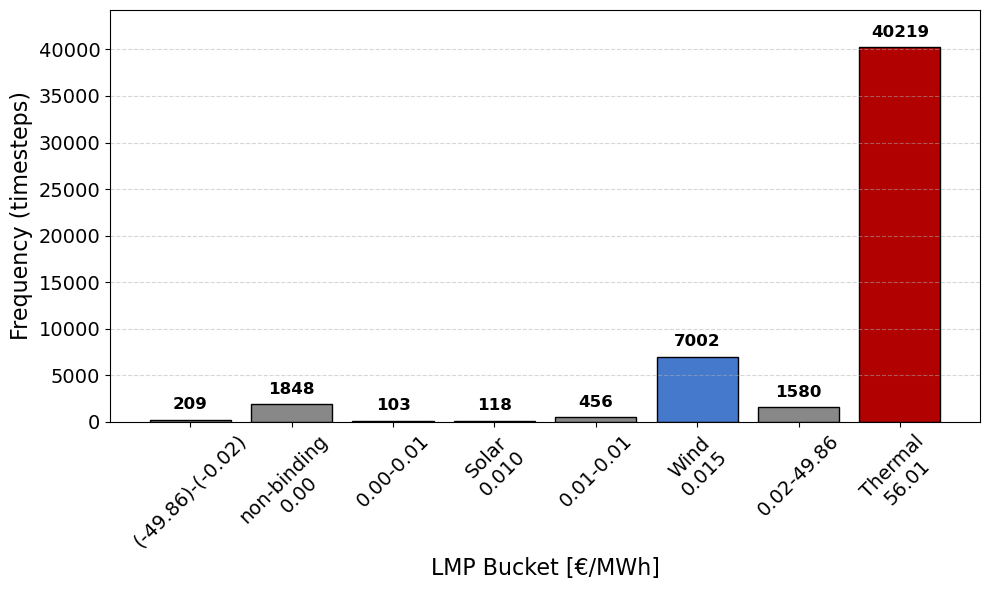

In [84]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [85]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,99,0.191327
gap_curtailment_neg_thermal,-90.000000,-62.172437,8,0.015461
neg_thermal,-62.172437,-49.857273,69,0.133349
gap_neg_thermal_neg_wind,-49.857273,-0.016500,209,0.403912
neg_wind,-0.016500,-0.013500,24,0.046382
gap_neg_wind_neg_solar,-0.013500,-0.011000,9,0.017393
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,1848,3.571429


LMP Bucket Relative Frequencies (%)


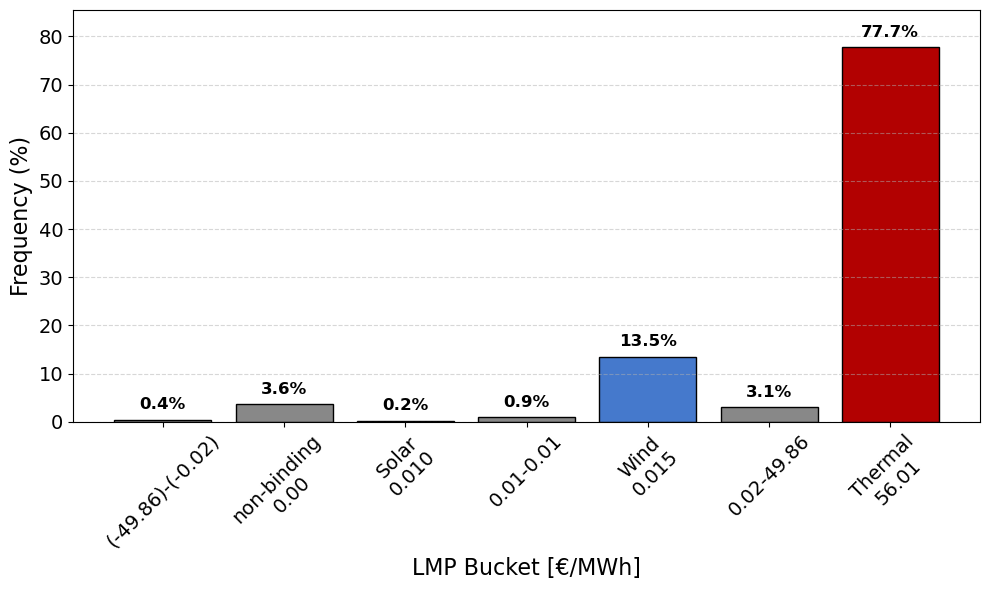

In [86]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

In [87]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 56.65078907769784
Year: 2030, Scenario: NT, max dual: 57.911107421396125
Year: 2040, Scenario: NT, max dual: 59.1781081741198
Year: 2040, Scenario: GA, max dual: 58.483087770486605
Year: 2040, Scenario: DE, max dual: 59.1781081741198
Year: 2050, Scenario: GA, max dual: 59.17810817411981
Year: 2050, Scenario: DE, max dual: 60.24621278331866


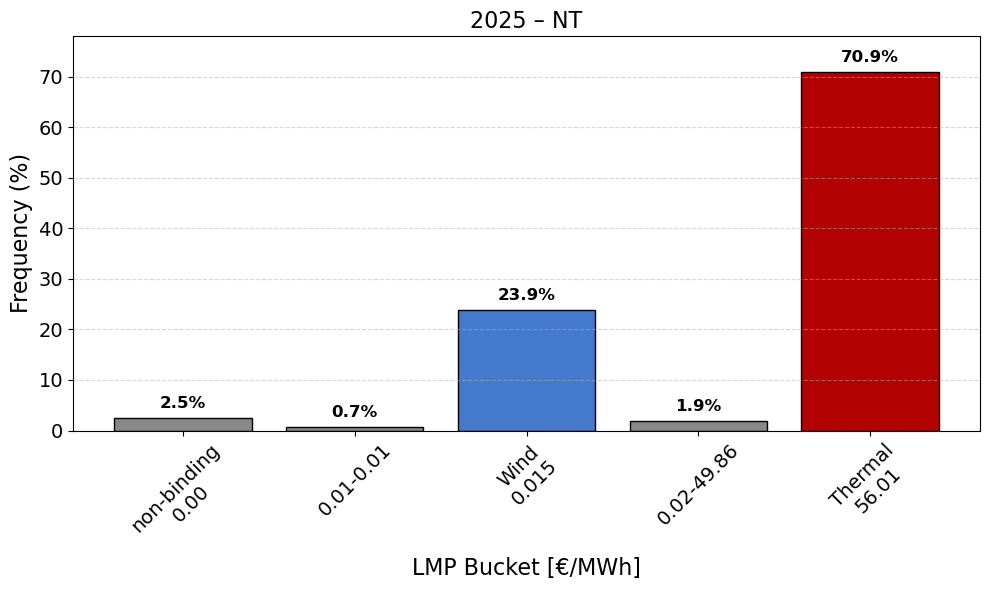

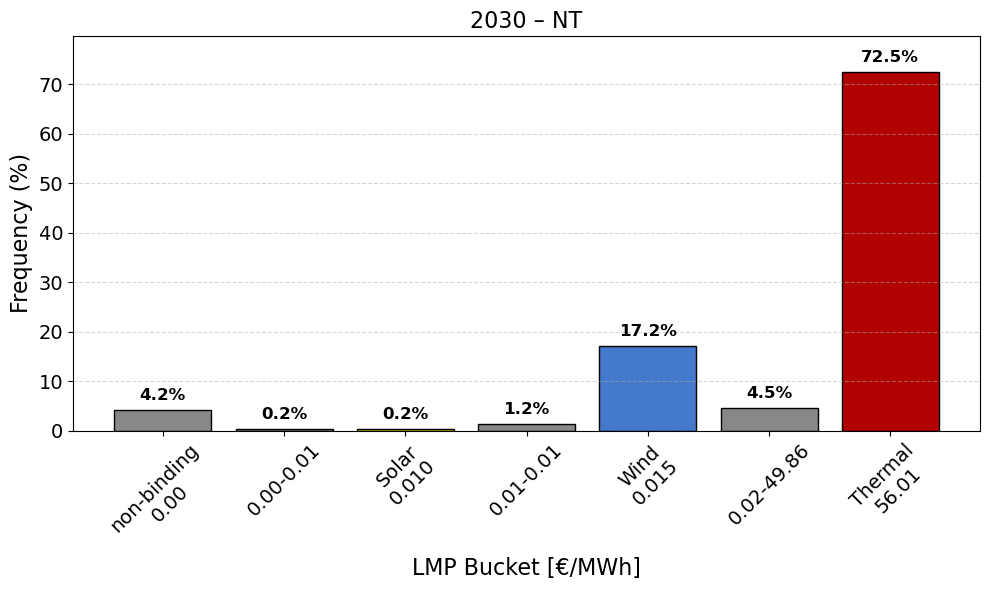

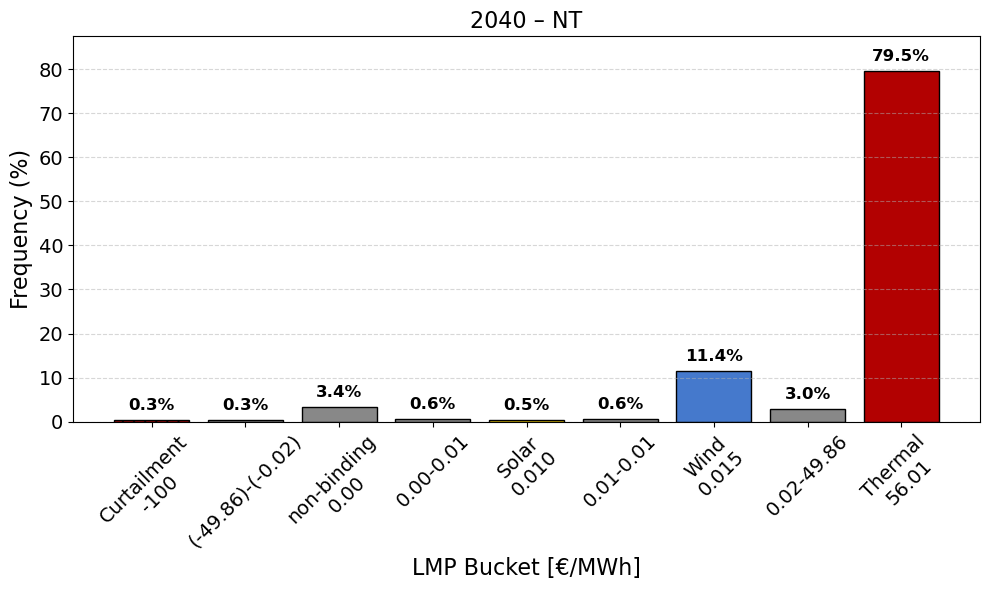

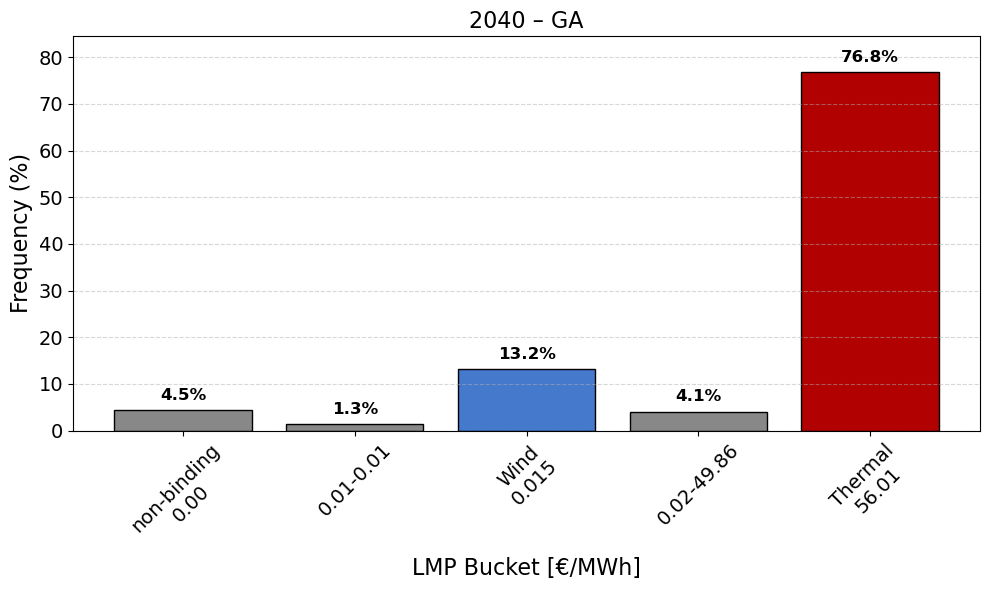

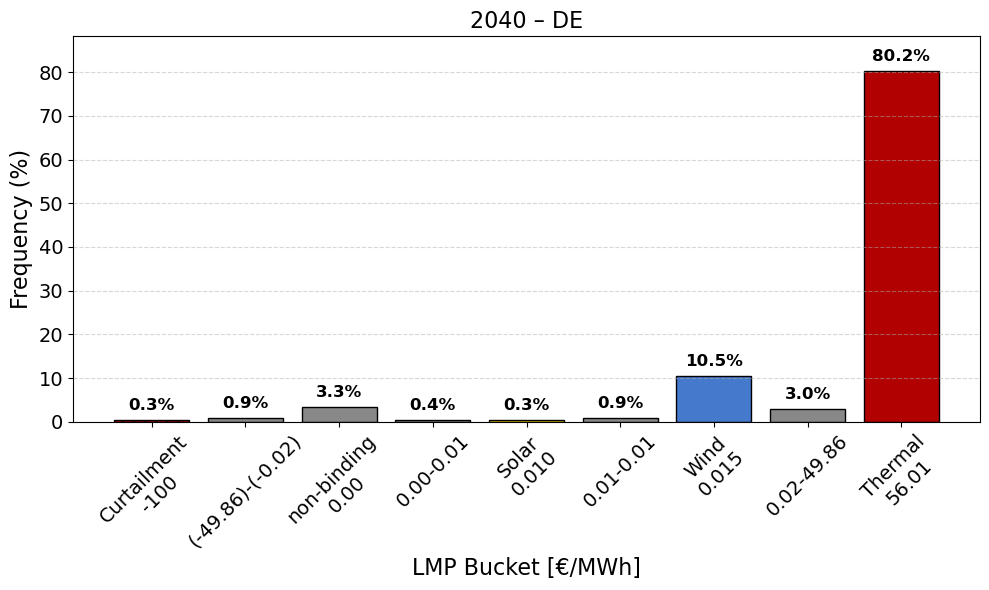

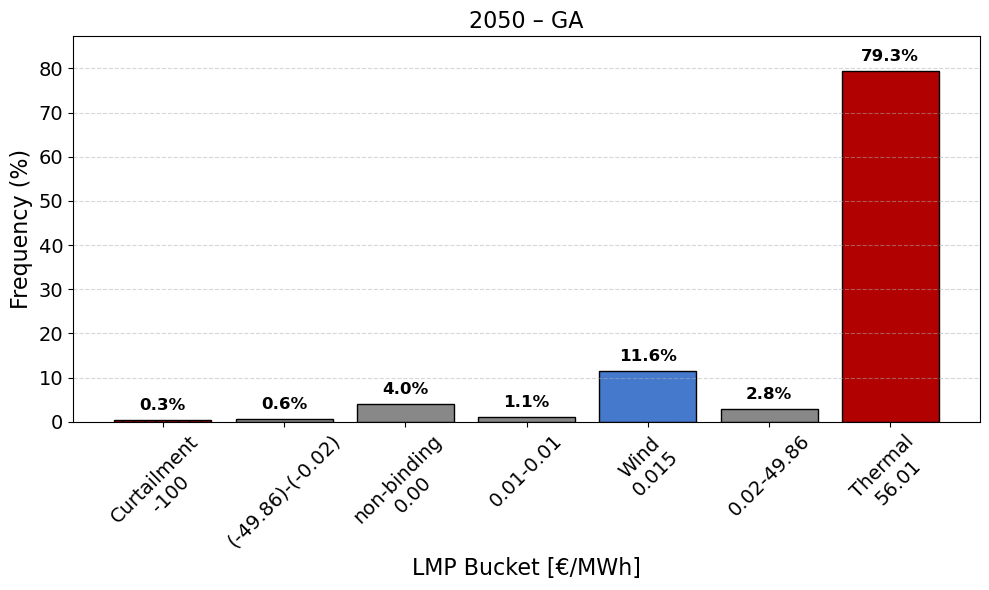

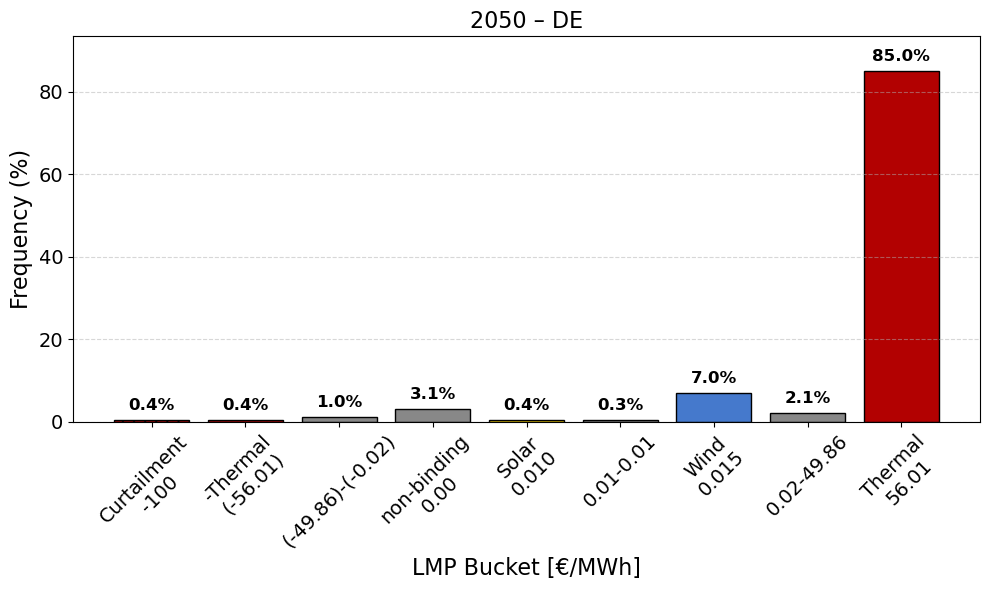

In [88]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

In [89]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,99,0.191327
gap_curtailment_neg_thermal,-90.000000,-62.172437,8,0.015461
neg_thermal,-62.172437,-49.857273,69,0.133349
gap_neg_thermal_neg_wind,-49.857273,-0.016500,209,0.403912
neg_wind,-0.016500,-0.013500,24,0.046382
gap_neg_wind_neg_solar,-0.013500,-0.011000,9,0.017393
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,1848,3.571429


In [90]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:

    cap = freqs.loc[freqs.index != "other", "upper"].max()

    analytics.plot_high_lmp_event_counts(
        power_balance_duals, cap, savefolder=dual_folder
    )

    analytics.plot_high_lmp_distribution(
        power_balance_duals, cap, n_bins=100, savefolder=dual_folder
    )

    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
    )
    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )
    print(top5)
    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

In [91]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
    )

    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )

    print(top5)

    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

In [92]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    # Assuming you've already built `high_tbl`:

    analytics.plot_top_high_bucket_detail(
        power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
    )

In [93]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014990  1.0     1.0
                         1       0.014869  1.0     1.0
                         2       0.014869  1.0     1.0
                         3       0.014869  1.0     1.0
                         4      -0.000000  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 52   163    56.515166  0.5     2.0
                         164    56.515166  0.5     2.0
                         165    56.515166  0.5     2.0
                         166    55.765060  0.5     2.0
                         167    55.454769  0.5     2.0

[51744 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT               7392           139                 1.880411
2030 NT               7392           333                 4.504870
2040 DE               7392           223                 3.016775
     GA               7392           301                 4.071970
     NT               7392           220                 2.976190
2050 DE               7392           154                 2.083333
     GA               7392           210                 2.840909
Distribution of LMPs in bucket 'gap_wind_thermal'


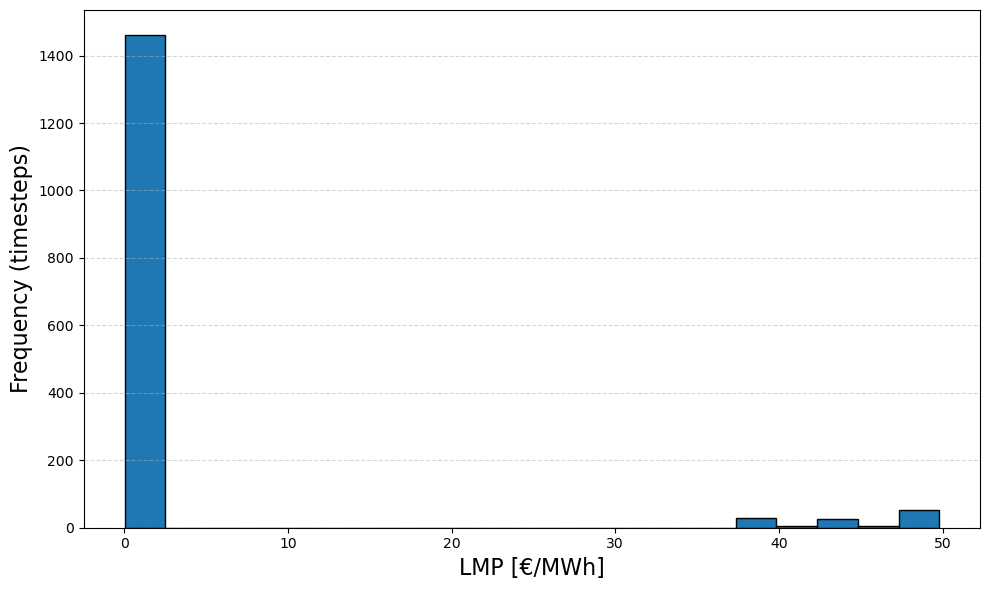

In [94]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

In [95]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    analytics.plot_lmp_histogram_70plus(
        power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
    )

In [96]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    freq_table = analytics.make_lmp_frequency_table(
        power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
    )

    with pd.option_context("display.max_rows", None, "display.max_columns", None):

        sorted_freq_table = freq_table.sort_values(by="count", ascending=False)

        display(sorted_freq_table)

In [97]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [98]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [99]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    38.818349
2030    39.817451
2040    43.078562
2050    44.714663
Name: dual_value, dtype: float64

In [100]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    7                0               4
     coal                    2                0               3
     offwind-ac              3                1               5
     onwind                  4                1               6
     ror                     0                0               4
     solar                   6                0               5
2030 CCGT                    6                1               4
     coal                    2                0               3
     offwind-ac              2                1               6
     onwind                  4                0               7
     ror                     0                0               4
     solar                   6                0               5
2040 CCGT                    5                1               5
     coal                    2                0               3
     offwind-ac              2                0               7
     onwind                  3                1               7
     ror                     0                0               4
     solar                   4                2               5
2050 CCGT                    5                0               6
     coal                    2                0               3
     offwind-ac              2                0               7
     onwind                  2                1               8
     ror                     0                0               4
     solar                   2                2               7

In [101]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,51744,6437,12.440090
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,51744,794,1.534477
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,3,3.947368
branch_flow_new_duals_max,89376,10664,11.931615
branch_flow_new_duals_min,89376,33453,37.429511
branch_flow_old_duals_max,89376,10648,11.913713
branch_flow_old_duals_min,89376,33432,37.406015


In [102]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT               7392           1314   
                                2030 NT               7392           1315   
                                2040 DE               7392            729   
                                     GA               7392            928   
                                     NT               7392            776   
                                2050 DE               7392            504   
                                     GA               7392            871   
battery_discharge_new_max_duals 2025 NT               7392            116   
                                2030 NT               7392             93   
                                2040 DE               7392            115   
                                     GA               7392            113   
                                     NT               7392            121   
                                2050 DE               7392            124   
                                     GA               7392            112   
branch_extension_duals          2025 All                19              2   
                                2030 All                19              1   
                                2040 All                19              0   
                                2050 All                19              0   
branch_flow_new_duals_max       2025 NT              12768           1206   
                                2030 NT              12768           1636   
                                2040 DE              12768           1568   
                                     GA              12768           1521   
                                     NT              12768           1567   
                                2050 DE              12768           1623   
                                     GA              12768           1543   
branch_flow_new_duals_min       2025 NT              12768           5035   
                                2030 NT              12768           4570   
                                2040 DE              12768           4793   
                                     GA              12768           4730   
                                     NT              12768           4790   
                                2050 DE              12768           4767   
                                     GA              12768           4768   
branch_flow_old_duals_max       2025 NT              12768           1201   
                                2030 NT              12768           1634   
                                2040 DE              12768           1566   
                                     GA              12768           1519   
                                     NT              12768           1565   
                                2050 DE              12768           1622   
                                     GA              12768           1541   
branch_flow_old_duals_min       2025 NT              12768           5029   
                                2030 NT              12768           4561   
                                2040 DE              12768           4793   
                                     GA              12768           4728   
                                     NT              12768           4788   
                                2050 DE              12768           4766   
                                     GA              12768           4767   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [103]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 PT1 1 ror        -310656.492449
     PT1 0 ror        -298663.479765
     ES1 4 offwind-ac -236305.807714
     PT1 1 solar      -178341.082382
     ES1 8 ror        -152643.864540
...                              ...
2050 ES1 6 offwind-ac     -20.000000
     ES1 1 solar          -10.000000
     ES1 2 solar          -10.000000
     ES1 5 onwind         -10.000000
     ES1 8 CCGT           -10.000000

[122 rows x 1 columns]

In [104]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99012.729293
coal          349961.553630
offwind-ac    184181.306769
onwind         96070.888020
ror           299125.224929
solar          35587.071244
Name: capital_cost, dtype: float64